In [57]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

dataset = pd.read_csv('data/insurance.csv')
df = pd.DataFrame(dataset)

# Suppression des doublons
df = df.drop_duplicates()

In [58]:
# Encodage des variables catégorielles
df["sex"] = df["sex"].map({"male": 0, "female": 1})

# Les boolean sont transformés en entier pour le modèle
df["smoker"] = df["smoker"].map({"yes": 1, "no": 0})
df["overweight"] = (df["bmi"] > 25).astype(int)

# One hot encoding pour la région
region_dummies = pd.get_dummies(df["region"], drop_first=True)
df = pd.concat([df, region_dummies], axis=1)

X = df.drop(["charges", "region"], axis=1)
y = np.log(df["charges"])  # Transformation log pour gérer la skewness

# Split des données (20% pour le test avec un seed fixe pour éviter le mélange)
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [59]:
# Normalisation (APRES le split)

# Interaction BMI - Smoker
X_train["bmi_smoker"] = X_train["bmi"] * X_train["smoker"]
X_test["bmi_smoker"] = X_test["bmi"] * X_test["smoker"]

scaler = MinMaxScaler()

# Normalisation de l'age pour le JDD train
X_train["age_scaled"] = scaler.fit_transform(X_train[["age"]])

# Normalisation de l'age pour le JDD test
X_test["age_scaled"] = scaler.transform(X_test[["age"]])

# Normalisation de children pour le JDD train
X_train["children_scaled"] = scaler.fit_transform(X_train[["children"]])

# Normalisation de children pour le JDD test
X_test["children_scaled"] = scaler.transform(X_test[["children"]])

# Normalisation du BMI pour le JDD train
X_train["bmi_scaled"] = scaler.fit_transform(X_train[["bmi"]])

# Normalisation du BMI pour le JDD test
X_test["bmi_scaled"] = scaler.transform(X_test[["bmi"]])

# Normalisation du BMI pour le JDD train
X_train["bmi_smoker_scaled"] = scaler.fit_transform(X_train[["bmi_smoker"]])

# Normalisation du BMI pour le JDD test
X_test["bmi_smoker_scaled"] = scaler.transform(X_test[["bmi_smoker"]])

In [60]:
# Selection des features à conserver pour l'entrainement
features_to_keep = [
    "sex",
    "smoker",
    "overweight",
    "northwest",
    "southeast",
    "southwest",
    "age_scaled",
    "bmi_smoker_scaled",
]

In [61]:


# Entrainement du modèle
model = LinearRegression()
model.fit(X_train, Y_train)

# Prédiction avec les données du dataset de test
y_pred = model.predict(X_test)

# Annulation du log
y_pred_euros = np.exp(y_pred)
y_test_euros = np.exp(Y_test)

# Calcul des métriques
r2 = r2_score(Y_test, y_pred) # Précision
mae = mean_absolute_error(y_test_euros, y_pred_euros) # Erreur en dollars
rmse = root_mean_squared_error(y_test_euros, y_pred_euros)

print(f"R2 Score : {r2:.3f}")
print(f"MAE : {mae:.2f} €")
print(f"RMSE : {rmse:.2f} €")

# Un écart faible signifie que les prédictions ne sont pas influencées par les valeurs aberrantes
print(f"Moyenne Réelle : {Y_test.mean():.2f} €")
print(f"Moyenne Prédite : {y_pred.mean():.2f} €")

R2 Score : 0.837
MAE : 4175.21 €
RMSE : 8644.56 €
Moyenne Réelle : 9.13 €
Moyenne Prédite : 9.17 €


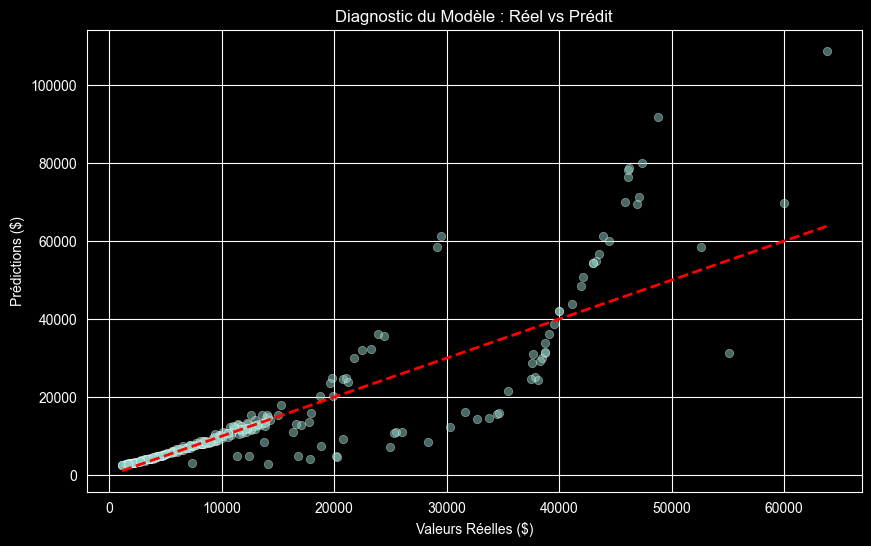

In [62]:
# Affichage d'un nuage de points pour évaluer le modèle

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_euros, y=y_pred_euros, alpha=0.5)
plt.plot([y_test_euros.min(), y_test_euros.max()], [y_test_euros.min(), y_test_euros.max()], '--r', lw=2)

plt.xlabel('Valeurs Réelles ($)')
plt.ylabel('Prédictions ($)')
plt.title('Diagnostic du Modèle : Réel vs Prédit')
plt.show()